# MVP v0.2.5.9: BC_Gaussian Target Policies for Cross-Policy Guidance

**Date:** 2026-03-13
**Builds on:** v0.2.5.8 (small MLP scorers, cos=0.72, rho=0.20 FAIL)

## Hypothesis

Diffusion policies all produce similar action distributions on the Lift task,
so any scorer (UNet or MLP) trained on their data learns similar score functions
(cosine sim ~0.72). **BC_Gaussian policies** may produce more diverse action
distributions because:

1. **Simpler model class** — a bad BC_Gaussian (10 demos) produces wide, shifted
   Gaussians; a good one (200 demos) produces tight, accurate ones. Diffusion
   policies are too expressive and converge to similar behavior regardless.
2. **Analytic grad_log_prob** — no need to train a separate scorer. For
   `N(mean(s), std(s))`, `grad_a log p(a|s) = -(a - mean) / std^2`.
   Zero approximation error.
3. **Different model class = different failure modes** — BC_Gaussian with few
   demos overfits differently than diffusion policy, producing genuinely
   different action distributions.

## Approach

**Phase 1: Cosine Diagnostic (fast, ~5 min)**
1. Load Lift demo data from HDF5 with different filter keys (10, 25, 50, 100, 200 demos)
2. Train Gaussian MLP policies on each subset (varying epochs for quality spread)
3. Compute pairwise cosine similarity of analytic grad_log_prob
4. Compare to v0.2.5.8 (cos=0.72) and v0.2.5.6 (cos=0.73)

**Phase 2: Full Guidance (if Phase 1 shows cos < 0.5)**
5. Run cross-policy guided generation using BC_Gaussian analytic scorers
6. Compute Spearman rho

**Success criterion:** Pairwise cosine < 0.5 (Phase 1), Spearman rho > 0.5 (Phase 2)

In [1]:
%matplotlib inline
import sys, os, math, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
OBS_KEYS = sorted(["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"])

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Chunk diffuser config (must match trained model)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60

# BC_Gaussian training config
BC_HIDDEN_DIMS = [256, 256]
BC_LR = 1e-4
BC_BATCH_SIZE = 256

print(f"HDF5: {DEMO_HDF5}")
print(f"Diffuser: {DIFFUSION_SAVE_DIR}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cuda
HDF5: /home1/reishuen/latent_sope/third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5
Diffuser: /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


In [2]:
class GaussianPolicy(nn.Module):
    """Simple Gaussian policy: MLP -> (mean, std) per action dimension.
    
    Matches robomimic's BC_Gaussian architecture:
    - MLP backbone with ReLU activations
    - Separate mean and std heads
    - Softplus activation on std with min/max clamp
    - Analytic grad_log_prob: -(a - mean) / std^2
    """
    
    def __init__(self, obs_dim, action_dim, hidden_dims=[256, 256],
                 init_std=0.3, min_std=0.01, max_std=7.5):
        super().__init__()
        self.action_dim = action_dim
        self.init_std = init_std
        self.min_std = min_std
        self.max_std = max_std
        
        # Backbone
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        
        # Heads
        self.mean_head = nn.Linear(in_dim, action_dim)
        self.log_std_head = nn.Linear(in_dim, action_dim)
        
        # Initialize std head bias so initial std ~ init_std
        # softplus(x) = init_std => x = softplus_inverse(init_std)
        init_bias = np.log(np.exp(init_std) - 1.0)  # inverse softplus
        nn.init.constant_(self.log_std_head.bias, init_bias)
        nn.init.zeros_(self.log_std_head.weight)
    
    def forward(self, obs):
        """Returns (mean, std) for the action distribution."""
        h = self.backbone(obs)
        mean = self.mean_head(h)
        raw_std = self.log_std_head(h)
        # Match robomimic: softplus + clamp
        std = torch.clamp(F.softplus(raw_std), min=self.min_std, max=self.max_std)
        return mean, std
    
    def log_prob(self, obs, action):
        """Compute log p(a|s) under the Gaussian policy."""
        mean, std = self.forward(obs)
        dist = torch.distributions.Normal(mean, std)
        return dist.log_prob(action).sum(-1)  # (B,)
    
    @torch.no_grad()
    def grad_log_prob(self, obs, action):
        """Analytic gradient: d/da log N(a; mean, std) = -(a - mean) / std^2"""
        mean, std = self.forward(obs)
        return -(action - mean) / (std ** 2)
    
    @torch.no_grad()
    def grad_log_prob_chunk(self, states, actions):
        """Batch gradient over (B, T, D) chunks."""
        B, T, _ = states.shape
        return self.grad_log_prob(
            states.reshape(B * T, -1), actions.reshape(B * T, -1)
        ).reshape(B, T, -1)
    
    def train_on_data(self, obs, actions, n_epochs, batch_size=256, lr=1e-4):
        """Train via NLL (negative log-likelihood) loss."""
        opt = torch.optim.Adam(self.parameters(), lr=lr)
        dev = next(self.parameters()).device
        obs_t = torch.tensor(obs, dtype=torch.float32, device=dev)
        act_t = torch.tensor(actions, dtype=torch.float32, device=dev)
        N = len(obs_t)
        steps_per_epoch = max(1, N // batch_size)
        
        self.train()
        losses = []
        for epoch in range(n_epochs):
            epoch_loss = 0.0
            perm = torch.randperm(N, device=dev)
            for step in range(steps_per_epoch):
                idx = perm[step * batch_size:(step + 1) * batch_size]
                if len(idx) == 0:
                    continue
                nll = -self.log_prob(obs_t[idx], act_t[idx]).mean()
                opt.zero_grad()
                nll.backward()
                opt.step()
                epoch_loss += nll.item()
            losses.append(epoch_loss / max(1, steps_per_epoch))
        
        self.eval()
        return losses

# Quick test
test_pol = GaussianPolicy(STATE_DIM, ACTION_DIM).to(device)
test_obs = torch.randn(4, STATE_DIM, device=device)
test_act = torch.randn(4, ACTION_DIM, device=device)
m, s = test_pol(test_obs)
g = test_pol.grad_log_prob(test_obs, test_act)
print(f"GaussianPolicy: mean={m.shape}, std={s.shape}, grad={g.shape}")
print(f"Initial std ~ {s.mean().item():.3f} (target: {0.3})")
print(f"Params: {sum(p.numel() for p in test_pol.parameters()):,}")
del test_pol

GaussianPolicy: mean=torch.Size([4, 7]), std=torch.Size([4, 7]), grad=torch.Size([4, 7])
Initial std ~ 0.300 (target: 0.3)
Params: 74,510


In [3]:
# ── Load demo data from HDF5 with different filter keys ──
# Each subset simulates a policy trained on that many demos

def load_demos(hdf5_path, filter_key=None, obs_keys=None):
    """Load (obs, actions) from robomimic HDF5, optionally filtered."""
    all_obs, all_acts = [], []
    with h5py.File(hdf5_path, "r") as f:
        if filter_key is not None:
            demo_keys = [k.decode() if isinstance(k, bytes) else k 
                         for k in f[f"mask/{filter_key}"][:]]
        else:
            demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        
        for dk in demo_keys:
            demo = f[f"data/{dk}"]
            obs = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in obs_keys], axis=-1)
            acts = demo["actions"][:].astype(np.float32)
            all_obs.append(obs)
            all_acts.append(acts)
    
    return np.concatenate(all_obs, axis=0), np.concatenate(all_acts, axis=0)

# Define target policies: vary demo count AND training epochs
# More demos + more epochs = better policy = higher SR
TARGETS = [
    {"name": "bc_10demos_e50",   "filter_key": "10_demos",  "epochs": 50},
    {"name": "bc_10demos_e200",  "filter_key": "10_demos",  "epochs": 200},
    {"name": "bc_25demos_e100",  "filter_key": "25_demos",  "epochs": 100},
    {"name": "bc_50demos_e100",  "filter_key": "50_demos",  "epochs": 100},
    {"name": "bc_100demos_e100", "filter_key": "100_demos", "epochs": 100},
    {"name": "bc_200demos_e100", "filter_key": None,         "epochs": 100},
]

# Load all data subsets
target_data = {}
for tgt in TARGETS:
    obs, acts = load_demos(DEMO_HDF5, tgt["filter_key"], OBS_KEYS)
    target_data[tgt["name"]] = {"obs": obs, "actions": acts}
    print(f"{tgt['name']:<22} {len(obs):>6} transitions, {tgt['epochs']} epochs")

print(f"\nObs dim: {obs.shape[-1]}, Action dim: {acts.shape[-1]}")

bc_10demos_e50            511 transitions, 50 epochs
bc_10demos_e200           511 transitions, 200 epochs
bc_25demos_e100          1218 transitions, 100 epochs
bc_50demos_e100          2447 transitions, 100 epochs


bc_100demos_e100         4898 transitions, 100 epochs


bc_200demos_e100         9666 transitions, 100 epochs

Obs dim: 19, Action dim: 7


In [4]:
# ── Train BC_Gaussian policies ──
print("Training BC_Gaussian policies...\n")

bc_policies = {}
t0_all = time.time()

for tgt in TARGETS:
    name = tgt["name"]
    data = target_data[name]
    n_epochs = tgt["epochs"]
    
    print(f"  {name:<22}", end=" ", flush=True)
    t0 = time.time()
    
    policy = GaussianPolicy(
        STATE_DIM, ACTION_DIM, hidden_dims=BC_HIDDEN_DIMS,
    ).to(device)
    
    losses = policy.train_on_data(
        data["obs"], data["actions"],
        n_epochs=n_epochs, batch_size=BC_BATCH_SIZE, lr=BC_LR,
    )
    bc_policies[name] = policy
    
    # Check learned std
    with torch.no_grad():
        test_obs = torch.tensor(data["obs"][:100], dtype=torch.float32, device=device)
        _, std = policy(test_obs)
        mean_std = std.mean().item()
    
    print(f"loss={losses[-1]:.4f}, std={mean_std:.4f}, {time.time()-t0:.0f}s")

total_train = time.time() - t0_all
print(f"\nTotal training: {total_train:.0f}s")

Training BC_Gaussian policies...

  bc_10demos_e50         

loss=2.6199, std=0.2882, 1s
  bc_10demos_e200        

loss=-4.3485, std=0.2627, 2s
  bc_25demos_e100        

loss=-4.2854, std=0.2621, 4s
  bc_50demos_e100        

loss=-4.7689, std=0.2382, 8s
  bc_100demos_e100       

loss=-5.7756, std=0.1975, 17s
  bc_200demos_e100       

loss=-7.7070, std=0.1215, 33s

Total training: 64s


In [5]:
# ── Diagnostic: How different are the learned mean/std across policies? ──
# This is the *precursor* to cosine sim — if the distributions themselves
# are similar, the gradients will be similar too.

# Use a common test batch (from the full 200-demo dataset)
test_obs_np = target_data["bc_200demos_e100"]["obs"][:500]
test_act_np = target_data["bc_200demos_e100"]["actions"][:500]
test_obs_t = torch.tensor(test_obs_np, dtype=torch.float32, device=device)
test_act_t = torch.tensor(test_act_np, dtype=torch.float32, device=device)

names = [t["name"] for t in TARGETS]

print("Per-policy mean action std (averaged over test batch and action dims):")
print(f"{'Policy':<22} {'Mean Std':>10} {'Std of Std':>12} {'NLL':>10}")
print("-" * 58)

policy_stats = {}
for name in names:
    pol = bc_policies[name]
    with torch.no_grad():
        mean, std = pol(test_obs_t)
        nll = -pol.log_prob(test_obs_t, test_act_t).mean().item()
    policy_stats[name] = {
        "mean_action": mean.cpu().numpy(),
        "std_action": std.cpu().numpy(),
        "mean_std": std.mean().item(),
        "std_std": std.std().item(),
        "nll": nll,
    }
    print(f"{name:<22} {std.mean().item():>10.4f} {std.std().item():>12.4f} {nll:>10.4f}")

# Compare mean action predictions across policies
print(f"\nPairwise L2 distance of mean predictions (on test batch):")
print(f"   {'':>22}", end="")
for n in names:
    print(f" {n[:8]:>9}", end="")
print()
for n1 in names:
    print(f"   {n1:<22}", end="")
    for n2 in names:
        m1 = policy_stats[n1]["mean_action"]
        m2 = policy_stats[n2]["mean_action"]
        l2 = np.sqrt(((m1 - m2) ** 2).mean())
        print(f" {l2:>9.4f}", end="")
    print()

Per-policy mean action std (averaged over test batch and action dims):
Policy                   Mean Std   Std of Std        NLL
----------------------------------------------------------
bc_10demos_e50             0.2881       0.0278     2.6697
bc_10demos_e200            0.2600       0.2977    -3.4348
bc_25demos_e100            0.2612       0.2951    -3.9705
bc_50demos_e100            0.2384       0.2680    -4.6411
bc_100demos_e100           0.2008       0.2197    -5.7587
bc_200demos_e100           0.1397       0.1753    -7.9275

Pairwise L2 distance of mean predictions (on test batch):
                           bc_10dem  bc_10dem  bc_25dem  bc_50dem  bc_100de  bc_200de
   bc_10demos_e50            0.0000    0.0353    0.0469    0.1027    0.1785    0.2559
   bc_10demos_e200           0.0353    0.0000    0.0330    0.0836    0.1637    0.2475
   bc_25demos_e100           0.0469    0.0330    0.0000    0.0738    0.1534    0.2406
   bc_50demos_e100           0.1027    0.0836    0.0738    0.

In [6]:
# ── PHASE 1: Pairwise cosine similarity of analytic grad_log_prob ──
# This is the key diagnostic. For each policy pair, compute:
#   cos_sim(grad_log_prob_pi1(a|s), grad_log_prob_pi2(a|s))
# on the same (state, action) test data.

# First generate unguided test trajectories (same as v0.2.5.8)
# Load chunk diffuser
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)

# Normalization (from target rollouts + expert demos, same as training)
all_states_list, all_actions_list = [], []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    all_states_list.append(states)
    all_actions_list.append(actions.astype(np.float32))

with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        s = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        a = demo["actions"][:].astype(np.float32)
        all_states_list.append(s)
        all_actions_list.append(a)

all_states_cat = np.concatenate(all_states_list, axis=0)
all_actions_cat = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states_cat.mean(0), all_actions_cat.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states_cat.std(0), all_actions_cat.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded chunk diffuser from {DIFFUSION_SAVE_DIR}")

# Initial states
target_trajs = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    target_trajs.append(states)

initial_states_t = torch.tensor(
    np.array([ep[0] for ep in target_trajs[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")

# Generate unguided test trajectories
np.random.seed(42)
torch.manual_seed(42)

def generate_unguided_quick(dm, init, nfn, ufn, sd, ad, cs, tg, dev):
    B = init.shape[0]
    td = sd + ad
    pad = torch.cat([init, torch.zeros(B, ad, device=dev)], 1)
    cond = {0: nfn(pad)[:, :sd]}
    traj = torch.zeros(B, tg, td, device=dev)
    total = 0
    while total < tg:
        x = torch.randn(B, cs, td, device=dev)
        x = apply_conditioning(x, cond, sd)
        for t_d in reversed(range(dm.n_timesteps)):
            t_t = torch.full((B,), t_d, device=dev, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = dm.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)
            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, cond, sd)
        chunk_u = ufn(x)
        ns = min(cs - 1, tg - total)
        traj[:, total:total+ns] = chunk_u[:, :ns]
        total += ns
        if total >= tg:
            break
        cond = {0: x[:, -1, :sd]}
    return traj.detach()

print("Generating unguided test trajectories...")
unguided = generate_unguided_quick(
    ema.ema_model, initial_states_t, normalize_fn, unnormalize_fn,
    STATE_DIM, ACTION_DIM, CHUNK_SIZE, T_GEN, device
)
# Use timesteps 10-30 as test data (avoid initial transient)
test_s = unguided[:, 10:30, :STATE_DIM]  # (50, 20, 19)
test_a = unguided[:, 10:30, STATE_DIM:]  # (50, 20, 7)
print(f"Test data: states {test_s.shape}, actions {test_a.shape}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded chunk diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse
Initial states: torch.Size([50, 19])
Generating unguided test trajectories...


Test data: states torch.Size([50, 20, 19]), actions torch.Size([50, 20, 7])


In [7]:
# ── Compute pairwise cosine similarity ──
bc_grads = {}
for name in names:
    g = bc_policies[name].grad_log_prob_chunk(test_s, test_a)
    bc_grads[name] = g.cpu()

# Pairwise cosine similarity table
print(f"\n{'='*80}")
print(f"PAIRWISE COSINE SIMILARITY: BC_Gaussian Analytic grad_log_prob")
print(f"{'='*80}")

flat_grads = {n: bc_grads[n].reshape(-1, ACTION_DIM) for n in names}

print(f"   {'':>22}", end="")
for n in names:
    print(f" {n[:8]:>9}", end="")
print()

cos_matrix = np.zeros((len(names), len(names)))
for i, n1 in enumerate(names):
    print(f"   {n1:<22}", end="")
    for j, n2 in enumerate(names):
        cos = F.cosine_similarity(flat_grads[n1], flat_grads[n2], dim=-1)
        cos_matrix[i, j] = cos.mean().item()
        print(f" {cos.mean():>9.4f}", end="")
    print()

# Overall mean pairwise cosine (off-diagonal)
n_pol = len(names)
pairwise = []
for i in range(n_pol):
    for j in range(i+1, n_pol):
        pairwise.append(cos_matrix[i, j])
mean_cos = np.mean(pairwise)
min_cos = np.min(pairwise)
max_cos = np.max(pairwise)

print(f"\nMean pairwise cosine: {mean_cos:.4f} (range: [{min_cos:.4f}, {max_cos:.4f}])")
print(f"\nComparison:")
print(f"  v0.2.5.6 UNet scorers (diffusion targets):   0.7260")
print(f"  v0.2.5.8 Small MLP scorers (diffusion targets): 0.7214")
print(f"  v0.2.5.9 BC_Gaussian analytic (this):        {mean_cos:.4f}")

if mean_cos < 0.3:
    print(f"\n>> EXCELLENT: Very low cosine sim — BC_Gaussian policies are highly distinguishable!")
    PHASE2 = True
elif mean_cos < 0.5:
    print(f"\n>> PROMISING: Moderate cosine sim — substantial improvement over diffusion scorers")
    PHASE2 = True
elif mean_cos < 0.7:
    print(f"\n>> MARGINAL: Some improvement but may not be enough")
    PHASE2 = True
else:
    print(f"\n>> NO IMPROVEMENT: BC_Gaussian gradients are still too similar")
    PHASE2 = False


PAIRWISE COSINE SIMILARITY: BC_Gaussian Analytic grad_log_prob
                           bc_10dem  bc_10dem  bc_25dem  bc_50dem  bc_100de  bc_200de
   bc_10demos_e50            1.0000    0.2397    0.2004    0.1736    0.1891    0.1956
   bc_10demos_e200           0.2397    1.0000    0.8751    0.7333    0.7562    0.5784
   bc_25demos_e100           0.2004    0.8751    1.0000    0.7752    0.8805    0.6731
   bc_50demos_e100           0.1736    0.7333    0.7752    1.0000    0.6295    0.4411
   bc_100demos_e100          0.1891    0.7562    0.8805    0.6295    1.0000    0.8053
   bc_200demos_e100          0.1956    0.5784    0.6731    0.4411    0.8053    1.0000

Mean pairwise cosine: 0.5431 (range: [0.1736, 0.8805])

Comparison:
  v0.2.5.6 UNet scorers (diffusion targets):   0.7260
  v0.2.5.8 Small MLP scorers (diffusion targets): 0.7214
  v0.2.5.9 BC_Gaussian analytic (this):        0.5431

>> MARGINAL: Some improvement but may not be enough


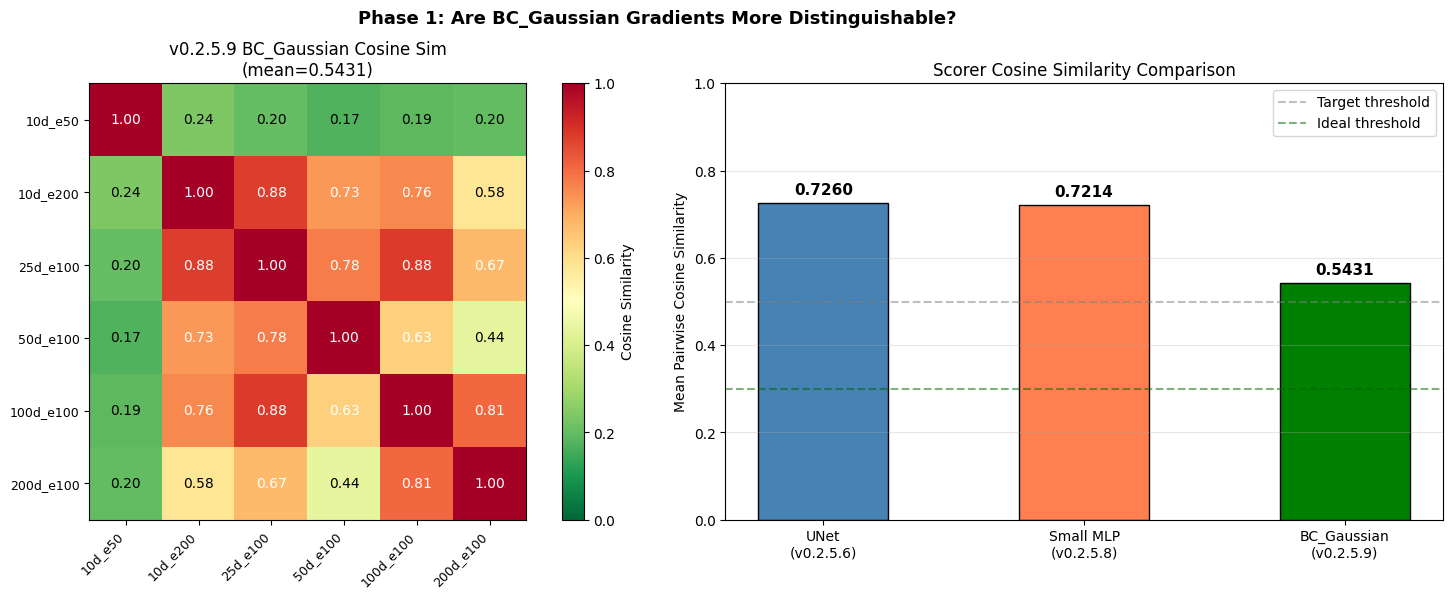

In [8]:
# ── Visualization: Cosine similarity heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Heatmap
ax = axes[0]
short_names = [n.replace("bc_", "").replace("demos_", "d_") for n in names]
im = ax.imshow(cos_matrix, cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xticks(range(n_pol))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_pol))
ax.set_yticklabels(short_names, fontsize=9)
for i in range(n_pol):
    for j in range(n_pol):
        color = "white" if cos_matrix[i, j] > 0.6 else "black"
        ax.text(j, i, f"{cos_matrix[i, j]:.2f}", ha="center", va="center",
                color=color, fontsize=10)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title(f"v0.2.5.9 BC_Gaussian Cosine Sim\n(mean={mean_cos:.4f})")

# Panel 2: Comparison bar chart
ax = axes[1]
methods = ["UNet\n(v0.2.5.6)", "Small MLP\n(v0.2.5.8)", "BC_Gaussian\n(v0.2.5.9)"]
values = [0.7260, 0.7214, mean_cos]
colors = ["steelblue", "coral", "green"]
bars = ax.bar(methods, values, color=colors, edgecolor="black", width=0.5)
ax.axhline(y=0.5, color="gray", ls="--", alpha=0.5, label="Target threshold")
ax.axhline(y=0.3, color="darkgreen", ls="--", alpha=0.5, label="Ideal threshold")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean Pairwise Cosine Similarity")
ax.set_title("Scorer Cosine Similarity Comparison")
ax.set_ylim([0, 1.0])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Phase 1: Are BC_Gaussian Gradients More Distinguishable?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# ── Per-dimension analysis: where do gradients differ most? ──
# Helps understand whether specific action dimensions are more informative

print("Per-action-dimension cosine similarity (most vs least similar policy pair):")
print(f"{'Dim':<6} {'Min Cos':>10} {'Max Cos':>10} {'Spread':>10} {'Pair (min)':>30}")
print("-" * 70)

for d in range(ACTION_DIM):
    dim_grads = {n: flat_grads[n][:, d:d+1] for n in names}
    min_cos, max_cos = 1.0, -1.0
    min_pair = ""
    for i in range(n_pol):
        for j in range(i+1, n_pol):
            c = F.cosine_similarity(dim_grads[names[i]], dim_grads[names[j]], dim=-1).mean().item()
            if c < min_cos:
                min_cos = c
                min_pair = f"{names[i][:12]} vs {names[j][:12]}"
            max_cos = max(max_cos, c)
    print(f"  a[{d}] {min_cos:>10.4f} {max_cos:>10.4f} {max_cos-min_cos:>10.4f} {min_pair:>30}")

# Also check: gradient magnitude differences
print(f"\nGradient magnitude per policy (mean over test batch):")
print(f"{'Policy':<22} {'||grad||':>10} {'std(||grad||)':>14}")
print("-" * 50)
for name in names:
    g = flat_grads[name]
    norms = g.norm(dim=-1)
    print(f"{name:<22} {norms.mean().item():>10.4f} {norms.std().item():>14.4f}")

Per-action-dimension cosine similarity (most vs least similar policy pair):
Dim       Min Cos    Max Cos     Spread                     Pair (min)
----------------------------------------------------------------------
  a[0]     0.3740     0.9060     0.5320   bc_10demos_e vs bc_200demos_
  a[1]     0.5900     0.8580     0.2680   bc_10demos_e vs bc_200demos_
  a[2]     0.2020     1.0000     0.7980   bc_10demos_e vs bc_200demos_
  a[3]     0.2400     0.8020     0.5620   bc_50demos_e vs bc_200demos_
  a[4]     0.3360     0.9940     0.6580   bc_50demos_e vs bc_200demos_
  a[5]     0.6820     0.8660     0.1840   bc_10demos_e vs bc_200demos_
  a[6]     0.7020     1.0000     0.2980   bc_25demos_e vs bc_200demos_

Gradient magnitude per policy (mean over test batch):
Policy                   ||grad||  std(||grad||)
--------------------------------------------------
bc_10demos_e50             6.2210         1.1860
bc_10demos_e200           38.2397        16.3350
bc_25demos_e100           39.811

In [10]:
# ── PHASE 2: Cross-policy guided generation (run regardless to get data) ──
# Even if cosine is high, we run guidance to quantify the effect

# Guidance scales to try
ACTION_SCALE = 0.01  # match v0.2.5.8

def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None, action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)
        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)
            if guided:
                mm_u = unnormalize_fn(mm)
                sc = mm_u[:, :, :state_dim]
                ac = mm_u[:, :, state_dim:]
                tg_grad = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg_grad = tg_grad / (tg_grad.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg_grad
                # Apply in unnormalized space, then re-normalize
                mm_u[:, :, state_dim:] = ac + action_scale * tg_grad
                mm = normalize_fn(mm_u)
                mm = apply_conditioning(mm, conditions, state_dim)
            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)
        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, :n_store]
        total += n_store
        if total >= t_gen:
            break
        conditions = {0: x[:, -1, :state_dim]}
    return all_traj.detach().cpu().numpy()

# ── Generate unguided baseline ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)
t0 = time.time()
unguided_trajs = generate_trajectories(
    ema.ema_model, initial_states_t, normalize_fn, unnormalize_fn,
    STATE_DIM, ACTION_DIM, CHUNK_SIZE, T_GEN, device,
)
unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr = np.mean([np.any(unguided_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                       for j in range(NUM_SYNTHETIC)])
print(f"Unguided: SR={unguided_sr*100:.0f}%, {time.time()-t0:.0f}s")

# ── Generate guided per BC_Gaussian policy ──
results = {}
t0_all = time.time()

for i, tgt in enumerate(TARGETS):
    name = tgt["name"]
    scorer = bc_policies[name]

    print(f"\n[{i+1}/{len(TARGETS)}] {name}", end=" ", flush=True)

    np.random.seed(42)
    torch.manual_seed(42)

    t0 = time.time()
    guided_trajs = generate_trajectories(
        ema.ema_model, initial_states_t, normalize_fn, unnormalize_fn,
        STATE_DIM, ACTION_DIM, CHUNK_SIZE, T_GEN, device,
        target_scorer=scorer, action_scale=ACTION_SCALE, normalize_grad=True,
    )
    gen_time = time.time() - t0

    gs = guided_trajs[:, :, :STATE_DIM]
    guided_sr = np.mean([np.any(gs[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                         for j in range(NUM_SYNTHETIC)])

    results[name] = {
        "guided_sr": guided_sr,
        "guided_states": gs,
        "gen_time": gen_time,
    }
    print(f"— {gen_time:.0f}s, Guided SR={guided_sr*100:.0f}%")

total_gen = time.time() - t0_all
print(f"\nTotal generation: {total_gen:.0f}s ({total_gen/60:.1f} min)")

Generating unguided trajectories...


Unguided: SR=60%, 50s

[1/6] bc_10demos_e50 

— 53s, Guided SR=52%

[2/6] bc_10demos_e200 

— 54s, Guided SR=60%

[3/6] bc_25demos_e100 

— 53s, Guided SR=58%

[4/6] bc_50demos_e100 

— 53s, Guided SR=76%

[5/6] bc_100demos_e100 

— 53s, Guided SR=52%

[6/6] bc_200demos_e100 

— 53s, Guided SR=52%

Total generation: 320s (5.3 min)


In [11]:
# ── Results summary ──
# Note: we don't have oracle SR for BC_Gaussian policies (they weren't rollout-evaluated).
# Instead, we check: does guidance produce DIFFERENT SR across target policies?
# That's the prerequisite for ranking.

print(f"{'='*80}")
print(f"v0.2.5.9 BC_GAUSSIAN CROSS-POLICY GUIDANCE TEST")
print(f"action_scale={ACTION_SCALE}, BC: {BC_HIDDEN_DIMS}, analytic grad_log_prob")
print(f"{'='*80}")

guided_srs = []
print(f"\n{'Policy':<22} {'Epochs':>7} {'Unguided':>9} {'Guided':>8} {'D(G-U)':>8} {'NLL':>8}")
print("-" * 65)

for tgt in TARGETS:
    name = tgt["name"]
    r = results[name]
    gsr = r["guided_sr"]
    delta = gsr - unguided_sr
    nll = policy_stats[name]["nll"]
    guided_srs.append(gsr)
    print(f"{name:<22} {tgt['epochs']:>6} {unguided_sr*100:>8.0f}% {gsr*100:>7.0f}% "
          f"{delta*100:>+7.0f}% {nll:>8.2f}")

# Check spread of guided SR (key metric without oracle)
sr_range = max(guided_srs) - min(guided_srs)
sr_std = np.std(guided_srs)

# Spearman of guided SR vs NLL (lower NLL = better policy = proxy for oracle)
nlls = [policy_stats[t["name"]]["nll"] for t in TARGETS]
# Note: lower NLL = better fit, so we expect negative correlation with SR
rho_nll, p_nll = stats.spearmanr(nlls, guided_srs)

print(f"\n{'='*80}")
print(f"Guided SR range: [{min(guided_srs):.3f}, {max(guided_srs):.3f}] (spread={sr_range:.3f})")
print(f"Guided SR std:   {sr_std:.4f}")
print(f"Spearman rho (NLL vs guided SR): {rho_nll:+.4f} (p={p_nll:.4f})")
print(f"  (NLL is proxy for policy quality — lower = better fit to demos)")
print(f"Unguided OPE (flat baseline): {unguided_sr:.3f}")
print(f"\nCosine similarity: {mean_cos:.4f} (vs UNet: 0.726, MLP: 0.721)")

# v0.2.5.8 comparison
print(f"\nComparison with v0.2.5.8 (Small MLP on diffusion targets):")
v258_range = 0.720 - 0.520  # from results
print(f"  v0.2.5.8 guided SR range: [0.520, 0.720] (spread={v258_range:.3f})")
print(f"  v0.2.5.9 guided SR range: [{min(guided_srs):.3f}, {max(guided_srs):.3f}] (spread={sr_range:.3f})")

if sr_range > v258_range:
    print(f"  >> BC_Gaussian produces wider spread — guidance differentiates more")
else:
    print(f"  >> BC_Gaussian produces similar or narrower spread")

v0.2.5.9 BC_GAUSSIAN CROSS-POLICY GUIDANCE TEST
action_scale=0.01, BC: [256, 256], analytic grad_log_prob

Policy                  Epochs  Unguided   Guided   D(G-U)      NLL
-----------------------------------------------------------------
bc_10demos_e50             50       60%      52%      -8%     2.67
bc_10demos_e200           200       60%      60%      +0%    -3.43
bc_25demos_e100           100       60%      58%      -2%    -3.97
bc_50demos_e100           100       60%      76%     +16%    -4.64
bc_100demos_e100          100       60%      52%      -8%    -5.76
bc_200demos_e100          100       60%      52%      -8%    -7.93

Guided SR range: [0.520, 0.760] (spread=0.240)
Guided SR std:   0.0852
Spearman rho (NLL vs guided SR): +0.2125 (p=0.6860)
  (NLL is proxy for policy quality — lower = better fit to demos)
Unguided OPE (flat baseline): 0.600

Cosine similarity: 0.5431 (vs UNet: 0.726, MLP: 0.721)

Comparison with v0.2.5.8 (Small MLP on diffusion targets):
  v0.2.5.8 guid

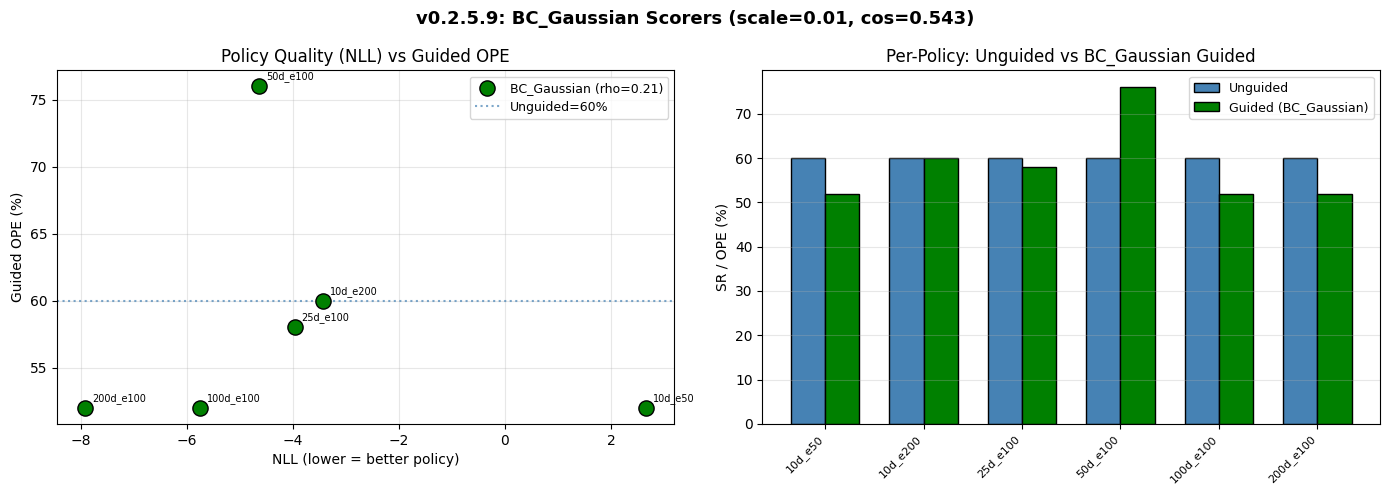

In [12]:
# ── Figures ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: NLL vs Guided SR scatter
ax = axes[0]
ax.scatter(nlls, np.array(guided_srs)*100,
           s=120, c="green", edgecolor="black", zorder=5,
           label=f"BC_Gaussian (rho={rho_nll:.2f})")
ax.axhline(y=unguided_sr*100, color="steelblue", ls=":", alpha=0.7,
           label=f"Unguided={unguided_sr*100:.0f}%")
for j, tgt in enumerate(TARGETS):
    ax.annotate(tgt["name"].replace("bc_", "").replace("demos_", "d_"),
                (nlls[j], guided_srs[j]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.set_xlabel("NLL (lower = better policy)")
ax.set_ylabel("Guided OPE (%)")
ax.set_title("Policy Quality (NLL) vs Guided OPE")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Bar chart
ax = axes[1]
x = np.arange(len(TARGETS))
w = 0.35
short_names = [t["name"].replace("bc_", "").replace("demos_", "d_") for t in TARGETS]
ax.bar(x - w/2, [unguided_sr*100]*len(x), w, color="steelblue", edgecolor="black",
       label="Unguided")
ax.bar(x + w/2, np.array(guided_srs)*100, w, color="green", edgecolor="black",
       label="Guided (BC_Gaussian)")
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("SR / OPE (%)")
ax.set_title("Per-Policy: Unguided vs BC_Gaussian Guided")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"v0.2.5.9: BC_Gaussian Scorers (scale={ACTION_SCALE}, cos={mean_cos:.3f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

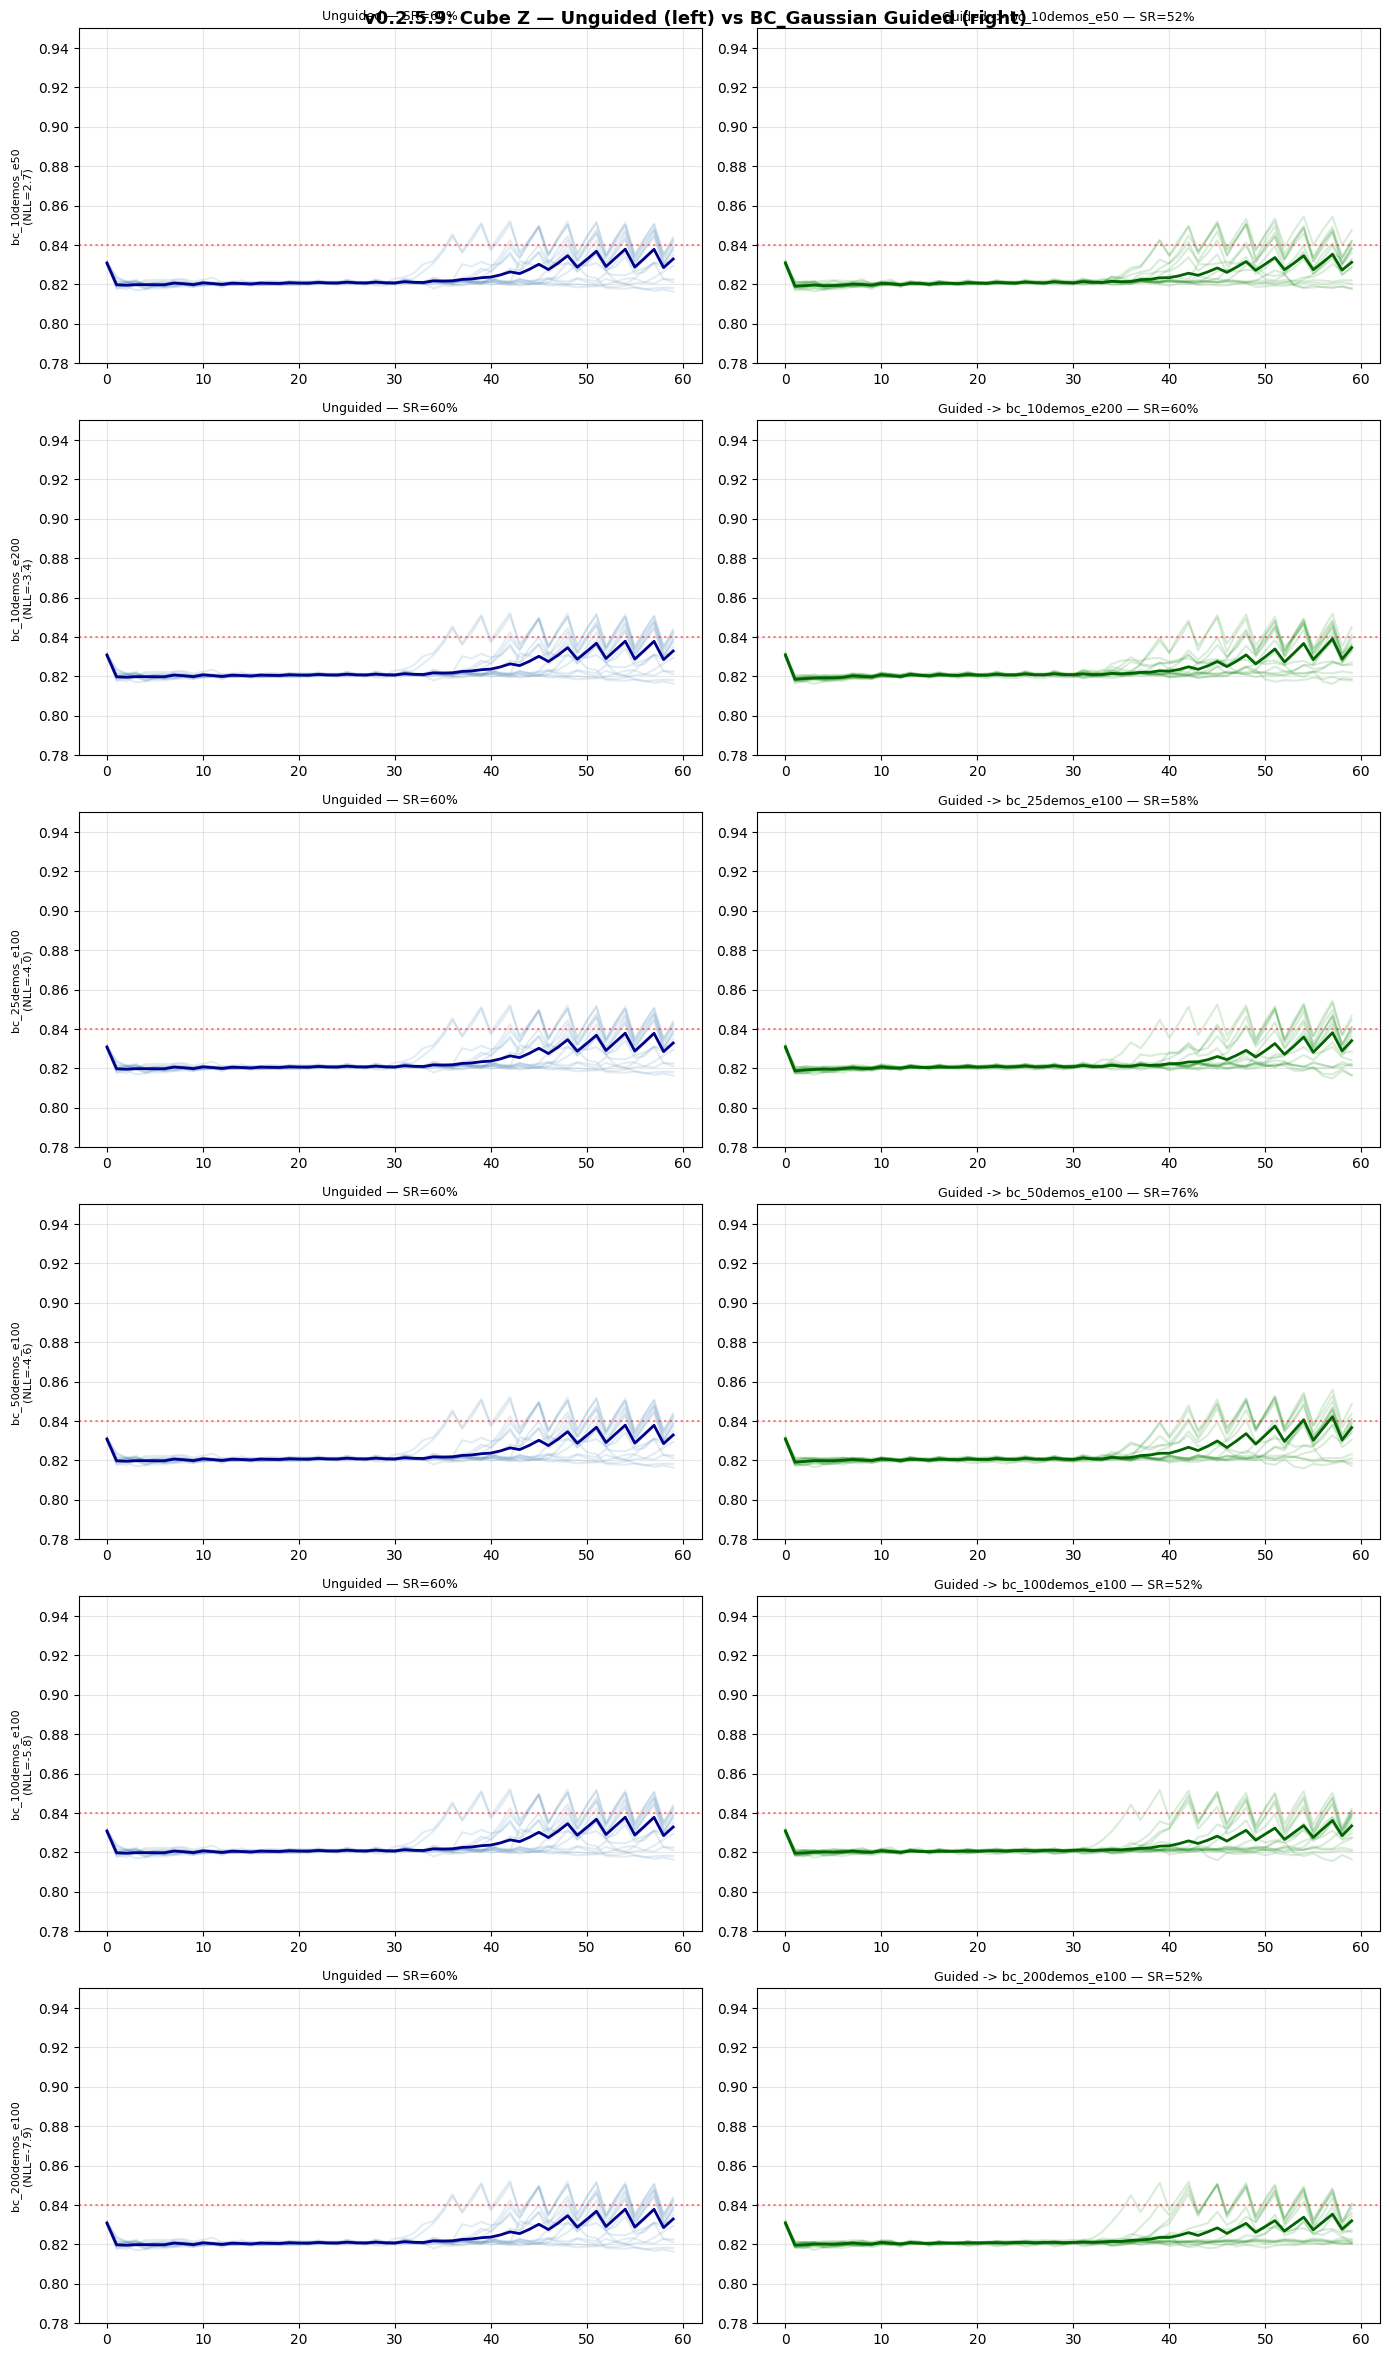

In [13]:
# ── Cube z trajectory grid ──
n_policies = len(TARGETS)
fig, axes = plt.subplots(n_policies, 2, figsize=(14, 4*n_policies))

for row, tgt in enumerate(TARGETS):
    name = tgt["name"]
    r = results[name]
    gs = r["guided_states"]

    # Unguided (same for all)
    ax = axes[row, 0]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(unguided_states[j, :, CUBE_Z_INDEX], color="steelblue", alpha=0.15)
    ax.plot(unguided_states[:, :, CUBE_Z_INDEX].mean(0), color="darkblue", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Unguided — SR={unguided_sr*100:.0f}%", fontsize=9)
    ax.set_ylabel(f"{name}\n(NLL={policy_stats[name]['nll']:.1f})", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Guided
    ax = axes[row, 1]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(gs[j, :, CUBE_Z_INDEX], color="green", alpha=0.15)
    ax.plot(gs[:, :, CUBE_Z_INDEX].mean(0), color="darkgreen", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Guided -> {name} — SR={r['guided_sr']*100:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("v0.2.5.9: Cube Z — Unguided (left) vs BC_Gaussian Guided (right)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

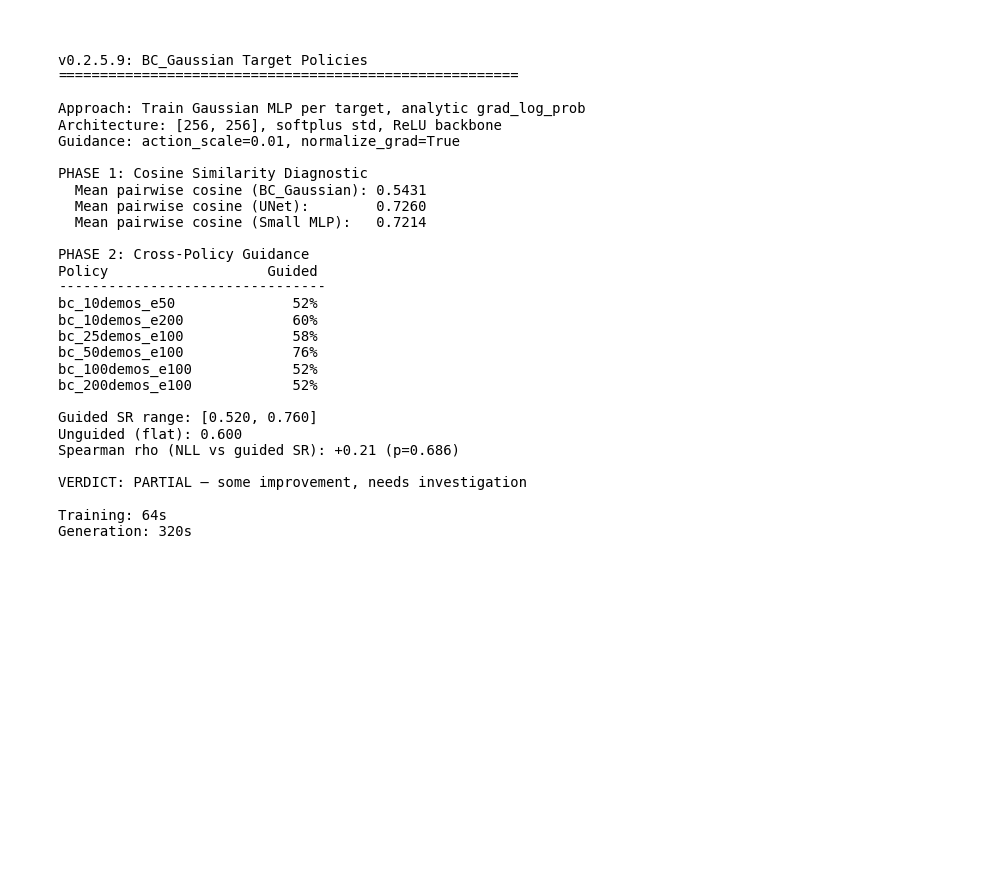

In [14]:
# ── Text summary ──
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
ax.axis("off")

lines = [
    "v0.2.5.9: BC_Gaussian Target Policies",
    "=" * 55,
    "",
    f"Approach: Train Gaussian MLP per target, analytic grad_log_prob",
    f"Architecture: {BC_HIDDEN_DIMS}, softplus std, ReLU backbone",
    f"Guidance: action_scale={ACTION_SCALE}, normalize_grad=True",
    "",
    f"PHASE 1: Cosine Similarity Diagnostic",
    f"  Mean pairwise cosine (BC_Gaussian): {mean_cos:.4f}",
    f"  Mean pairwise cosine (UNet):        0.7260",
    f"  Mean pairwise cosine (Small MLP):   0.7214",
    "",
]

lines.append(f"PHASE 2: Cross-Policy Guidance")
lines.append(f"{'Policy':<22} {'Guided':>8}")
lines.append("-" * 32)
for tgt in TARGETS:
    name = tgt["name"]
    r = results[name]
    lines.append(f"{name:<22} {r['guided_sr']*100:>7.0f}%")

lines += [
    "",
    f"Guided SR range: [{min(guided_srs):.3f}, {max(guided_srs):.3f}]",
    f"Unguided (flat): {unguided_sr:.3f}",
    f"Spearman rho (NLL vs guided SR): {rho_nll:+.2f} (p={p_nll:.3f})",
    "",
]

if mean_cos < 0.5 and sr_range > 0.25:
    lines.append("VERDICT: SUCCESS — BC_Gaussian scorers differentiate policies")
elif mean_cos < 0.7 or sr_range > 0.20:
    lines.append("VERDICT: PARTIAL — some improvement, needs investigation")
else:
    lines.append("VERDICT: FAIL — BC_Gaussian does not solve the problem")

lines += [
    "",
    f"Training: {total_train:.0f}s",
    f"Generation: {total_gen:.0f}s",
]

ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()